# Retail Demand Forecasting

## 1. Project Overview

Retail demand forecasting plays an important role in inventory management, purchasing, staffing, promotion planning, and operational decision-making.

This project develops a forecasting framework to predict future retail sales using historical demand patterns and relevant external factors.

### Objectives

- Analyze historical retail sales patterns and trends.
- Identify temporal and seasonal demand patterns.
- Examine the impact of promotions, holidays, and external factors.
- Develop time-series and machine learning forecasting models.
- Establish a seasonal naive baseline for model comparison.
- Evaluate forecasting performance using appropriate error metrics.
- Analyze forecast errors across stores, product families, and forecasting horizons.
- Translate model results into actionable business insights.

### Forecasting Target

**Target variable:** `sales`

### Dataset

The project uses the Kaggle Store Sales dataset, which contains transaction-level information across stores and product families together with promotional, holiday, and external economic information.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Environment initialized successfully.")

Environment initialized successfully.


In [4]:
DATA_DIR = "data"

TRAIN_PATH = os.path.join(DATA_DIR, "train.csv")
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
STORES_PATH = os.path.join(DATA_DIR, "stores.csv")
OIL_PATH = os.path.join(DATA_DIR, "oil.csv")
HOLIDAYS_PATH = os.path.join(DATA_DIR, "holidays_events.csv")
TRANSACTIONS_PATH = os.path.join(DATA_DIR, "transactions.csv")

In [5]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
stores = pd.read_csv(STORES_PATH)
oil = pd.read_csv(OIL_PATH)
holidays = pd.read_csv(HOLIDAYS_PATH)
transactions = pd.read_csv(TRANSACTIONS_PATH)

In [6]:
datasets = {
    "Train": train,
    "Test": test,
    "Stores": stores,
    "Oil": oil,
    "Holidays": holidays,
    "Transactions": transactions
}

dataset_summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

dataset_summary

,Dataset,Rows,Columns
0,Train,3000888,6
1,Test,28512,5
2,Stores,54,5
3,Oil,1218,2
4,Holidays,350,6
5,Transactions,83488,3


## 4. Main Dataset Overview

The training dataset contains historical observations used to understand demand patterns and develop forecasting models.

In [7]:
train.head()


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


## 5. Data Quality Assessment

Before performing exploratory analysis or model development, the structure, data types, missing values, and duplicate records are assessed.

In [9]:
quality_summary = pd.DataFrame({
    "Data Type": train.dtypes.astype(str),
    "Missing Values": train.isna().sum(),
    "Missing (%)": (train.isna().mean() * 100).round(2),
    "Unique Values": train.nunique()
})

quality_summary

,Data Type,Missing Values,Missing (%),Unique Values
id,int64,0,0.00,3000888
date,object,0,0.00,1684
store_nbr,int64,0,0.00,54
family,object,0,0.00,33
sales,float64,0,0.00,379610
onpromotion,int64,0,0.00,362


In [10]:
train.duplicated().sum()

np.int64(0)

## 6. Temporal Structure

The `date` variable is converted to a datetime format to support chronological analysis and time-series modelling.

In [11]:
train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

In [12]:
train = train.sort_values(
    ["date", "store_nbr", "family"]
).reset_index(drop=True)

test = test.sort_values(
    ["date", "store_nbr", "family"]
).reset_index(drop=True)

In [13]:
temporal_summary = pd.DataFrame({
    "Metric": [
        "Training Start",
        "Training End",
        "Testing Start",
        "Testing End",
        "Training Observations",
        "Testing Observations"
    ],
    "Value": [
        train["date"].min(),
        train["date"].max(),
        test["date"].min(),
        test["date"].max(),
        len(train),
        len(test)
    ]
})

temporal_summary

,Metric,Value
0,Training Start,2013-01-01 00:00:00
1,Training End,2017-08-15 00:00:00
2,Testing Start,2017-08-16 00:00:00
3,Testing End,2017-08-31 00:00:00
4,Training Observations,3000888
5,Testing Observations,28512


In [14]:
structure_summary = pd.DataFrame({
    "Metric": [
        "Number of Stores",
        "Number of Product Families",
        "Number of Training Dates",
        "Number of Testing Dates"
    ],
    "Value": [
        train["store_nbr"].nunique(),
        train["family"].nunique(),
        train["date"].nunique(),
        test["date"].nunique()
    ]
})

structure_summary

,Metric,Value
0,Number of Stores,54
1,Number of Product Families,33
2,Number of Training Dates,1684
3,Number of Testing Dates,16


## 7. Sales Overview

The target variable, `sales`, represents the quantity of products sold. Its distribution and aggregate behaviour provide the foundation for understanding overall demand before developing forecasting models.

In [15]:
sales_summary = train["sales"].describe()

sales_summary

count   3,000,888.00
mean          357.78
std         1,102.00
min             0.00
25%             0.00
50%            11.00
75%           195.85
max       124,717.00
Name: sales, dtype: float64

In [16]:
daily_sales = (
    train.groupby("date", as_index=False)["sales"]
    .sum()
)

daily_sales.head()

,date,sales
0,2013-01-01,"2,511.62"
1,2013-01-02,"496,092.42"
2,2013-01-03,"361,461.23"
3,2013-01-04,"354,459.68"
4,2013-01-05,"477,350.12"


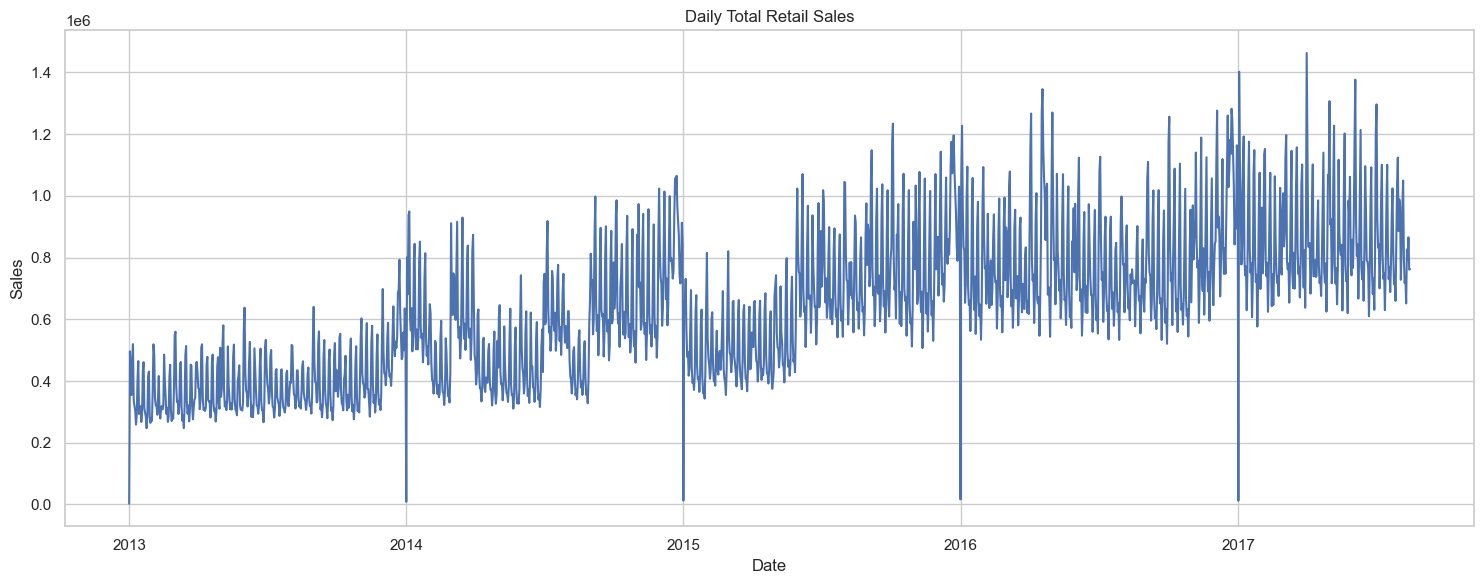

In [17]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales["date"],
    daily_sales["sales"]
)

plt.title("Daily Total Retail Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

## 8. Sales Distribution Across Product Families

Sales volume is examined across product families to identify the categories contributing most significantly to overall demand.

In [18]:
family_sales = (
    train.groupby("family")["sales"]
    .sum()
    .sort_values(ascending=False)
)

family_sales

family
GROCERY I                    343,462,734.89
BEVERAGES                    216,954,486.00
PRODUCE                      122,704,684.68
CLEANING                      97,521,289.00
DAIRY                         64,487,709.00
BREAD/BAKERY                  42,133,945.58
POULTRY                       31,876,004.47
MEATS                         31,086,468.40
PERSONAL CARE                 24,592,051.00
DELI                          24,110,322.47
HOME CARE                     16,022,744.00
EGGS                          15,588,296.00
FROZEN FOODS                  14,073,887.72
PREPARED FOODS                 8,799,895.12
LIQUOR,WINE,BEER               7,746,640.00
SEAFOOD                        2,015,431.88
GROCERY II                     1,962,767.00
HOME AND KITCHEN I             1,861,491.00
HOME AND KITCHEN II            1,520,670.00
CELEBRATION                      761,177.00
LINGERIE                         653,114.00
LADIESWEAR                       651,159.00
PLAYERS AND ELECTRONICS  

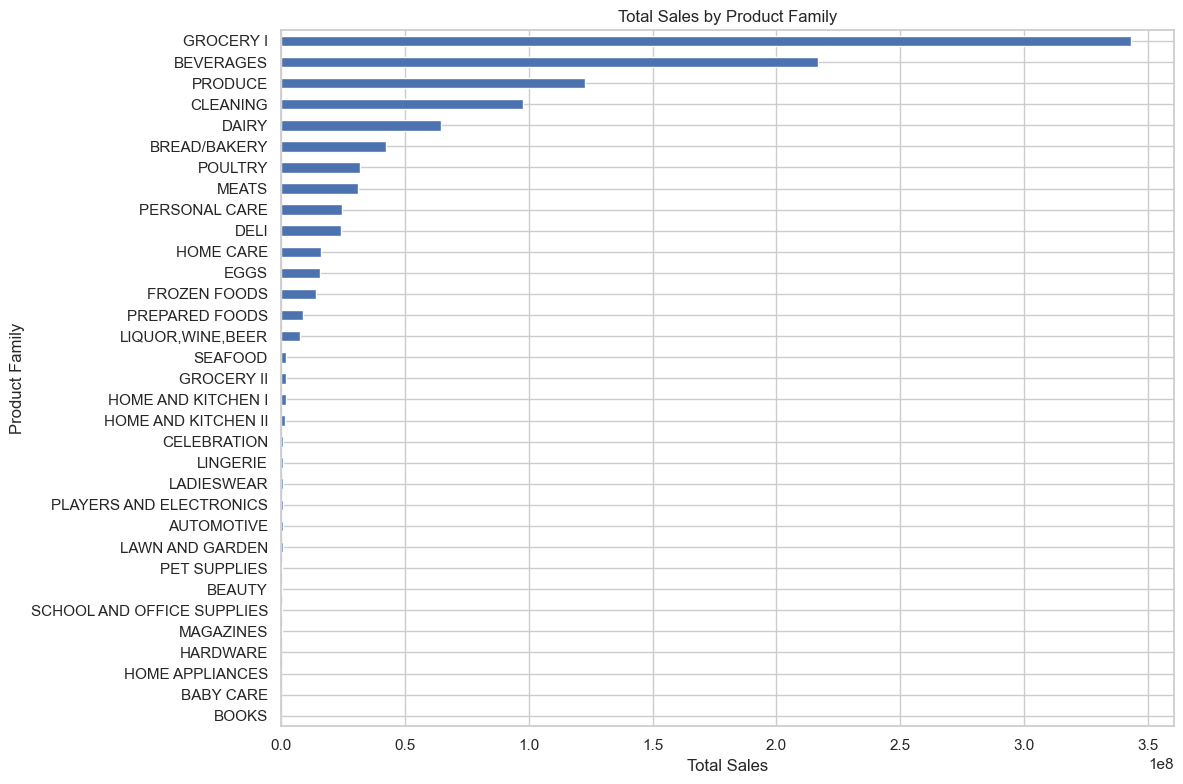

In [19]:
plt.figure(figsize=(12, 8))

family_sales.sort_values().plot(
    kind="barh"
)

plt.title("Total Sales by Product Family")
plt.xlabel("Total Sales")
plt.ylabel("Product Family")
plt.tight_layout()
plt.show()

## 9. Sales Distribution Across Stores

Store-level sales are examined to identify differences in demand across locations.

In [20]:
store_sales = (
    train.groupby("store_nbr")["sales"]
    .sum()
    .sort_values(ascending=False)
)

store_sales.head(10)

store_nbr
44   62,087,553.25
45   54,498,010.42
47   50,948,310.06
3    50,481,910.19
49   43,420,095.78
46   41,896,062.12
48   35,933,130.27
51   32,911,489.54
8    30,494,286.93
50   28,653,020.62
Name: sales, dtype: float64

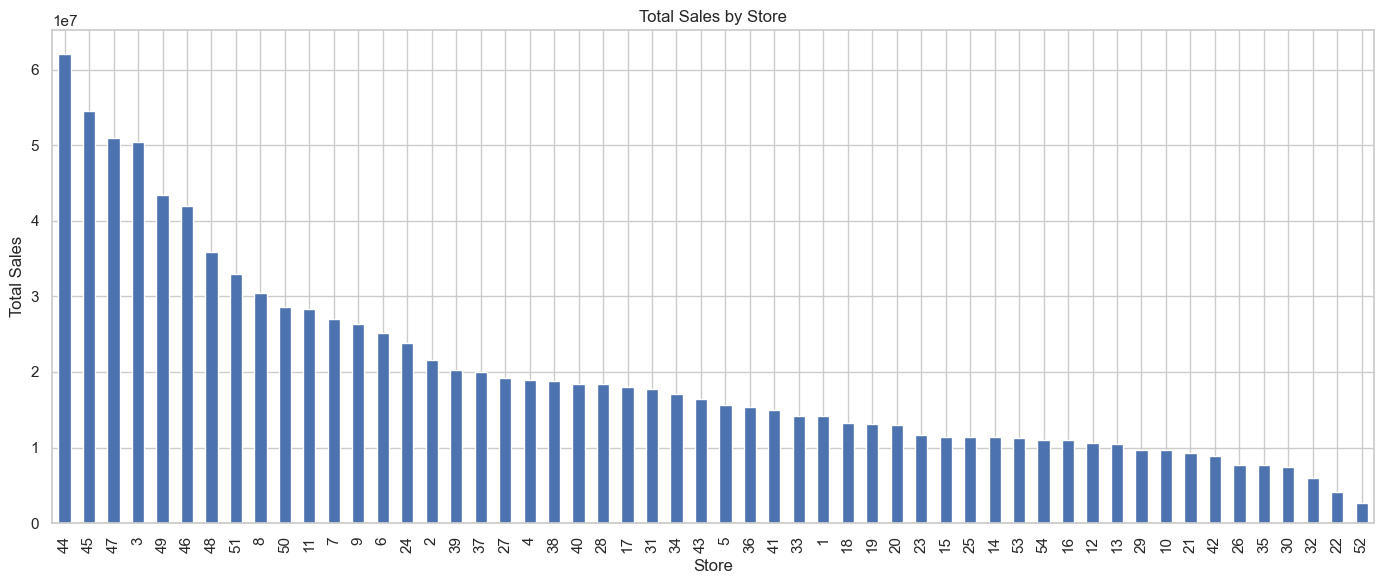

In [21]:
plt.figure(figsize=(14, 6))

store_sales.plot(kind="bar")

plt.title("Total Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()